<a href="https://colab.research.google.com/github/Mai732/ML-AI/blob/main/assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from collections import Counter

First 5 rows of the dataset:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0

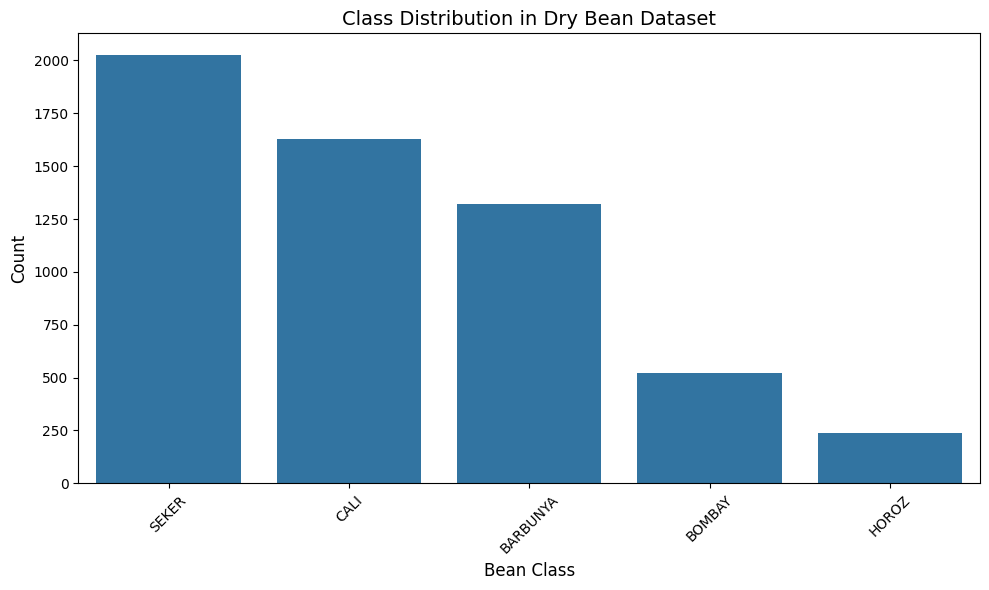

In [ ]:
# 1. Load the dataset and display the first five rows
df = pd.read_csv('Dry_Bean_Dataset.csv')
print("First 5 rows of the dataset:")
print(df.head())

# 2. Print total number of samples (rows) and features (columns)
print(f"\nTotal number of samples (rows): {df.shape[0]}")
print(f"Total number of features (columns): {df.shape[1]}")

# 3. How many unique classes are present?
unique_classes = df['Class'].unique()
print(f"\nNumber of unique classes: {len(unique_classes)}")
print(f"Classes: {unique_classes}")

# 4. Is the dataset balanced or imbalanced?
print("\nClass distribution:")
class_counts = df['Class'].value_counts()
print(class_counts)

# Check balance
min_count = class_counts.min()
max_count = class_counts.max()
ratio = max_count / min_count
print(f"\nMin class count: {min_count}, Max class count: {max_count}")
print(f"Ratio (max/min): {ratio:.2f}")

if ratio > 1.5:
    print("The dataset is IMBALANCED (ratio > 1.5)")
else:
    print("The dataset is BALANCED (ratio <= 1.5)")

# Visualization - Bar chart for class distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class', order=class_counts.index)
plt.title('Class Distribution in Dry Bean Dataset', fontsize=14)
plt.xlabel('Bean Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

print("Part 2: Data Preprocessing")
print("\nMissing values in each column:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\nHandling missing values...")
    # For numerical columns, fill with median
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64'] and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    # For categorical columns, fill with mode
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values handled.")

# 2. Detect and remove outliers using IQR method
print("\nDetecting outliers using IQR method...")

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Calculate IQR for each feature
outlier_counts = {}
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = X[(X[col] < lower_bound) | (X[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

print("\nOutlier counts per feature:")
for col, count in outlier_counts.items():
    print(f"  {col}: {count}")

# Remove rows with outliers (using any feature)
outlier_mask = pd.Series([False] * len(X))
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask = outlier_mask | ((X[col] < lower_bound) | (X[col] > upper_bound))

print(f"\nTotal rows before outlier removal: {len(df)}")
print(f"Rows with outliers: {outlier_mask.sum()}")
print(f"Rows after outlier removal: {len(df) - outlier_mask.sum()}")

# Remove outliers
df_clean = df[~outlier_mask].copy()
print(f"\nDataset shape after removing outliers: {df_clean.shape}")

# 4. Explanation of why feature scaling affects KNN performance
print("\n" + "="*50)
print("Why feature scaling significantly affects KNN performance:")
print("""
KNN is a distance-based algorithm that computes distances between data points.
Features with larger scales dominate the distance calculation, making the algorithm
sensitive to the magnitude of features. For example, if one feature ranges from
0-1000 and another from 0-1, the larger-scale feature will have disproportionate
influence on the distance metric. Scaling ensures all features contribute equally
to the distance calculation, leading to better and more reliable predictions.
""")


Part 2: Data Preprocessing

Missing values in each column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              1
dtype: int64

Handling missing values...
Missing values handled.

Detecting outliers using IQR method...

Outlier counts per feature:
  Area: 514
  Perimeter: 226
  MajorAxisLength: 107
  MinorAxisLength: 523
  AspectRation: 0
  Eccentricity: 8
  ConvexArea: 511
  EquivDiameter: 428
  Extent: 178
  Solidity: 99
  roundness: 13
  Compactness: 0
  ShapeFactor1: 481
  ShapeFactor2: 0
  ShapeFactor3: 0
  ShapeFactor4: 149

Total rows before outlier removal: 5741
Rows with outliers: 898
Rows after outlier removal: 4843

Dataset shape after removing outliers: (4843, 17)

Why feature 

/tmp/ipykernel_45080/1986102263.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:

print("Part 3: Train-Test Strategy")

X_clean = df_clean.drop('Class', axis=1)
y_clean = df_clean['Class']

# Scale the features (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# 1 & 2: Compare different splits
splits = {
    '70/30': 0.3,
    '80/20': 0.2
}

print("\nComparing different train-test splits with KNN (k=5):")
print("-"*60)

for split_name, test_size in splits.items():
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_clean, test_size=test_size, random_state=42, stratify=y_clean
    )

    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{split_name} split:")
    print(f"  Training size: {len(X_train)}, Test size: {len(X_test)}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}")

print("\nDiscussion: The 80/20 split typically gives slightly better performance")
print("because more training data helps KNN better understand the underlying")
print("patterns. However, the difference may be small if the dataset is large enough.")

Part 3: Train-Test Strategy

Comparing different train-test splits with KNN (k=5):
------------------------------------------------------------

70/30 split:
  Training size: 3390, Test size: 1453
  Accuracy: 0.9539
  F1-Score: 0.9535

80/20 split:
  Training size: 3874, Test size: 969
  Accuracy: 0.9556
  F1-Score: 0.9554

Discussion: The 80/20 split typically gives slightly better performance
because more training data helps KNN better understand the underlying
patterns. However, the difference may be small if the dataset is large enough.


Part 4: KNN Implementation & Hyperparameter Tuning

1. Baseline KNN Classifier (k=5):
  Accuracy: 0.9556
  F1-Score: 0.9554

2. Hyperparameter tuning (k values 1-25):

  Best k value: 4
  Best Accuracy: 0.9639
  Best F1-Score: 0.9639


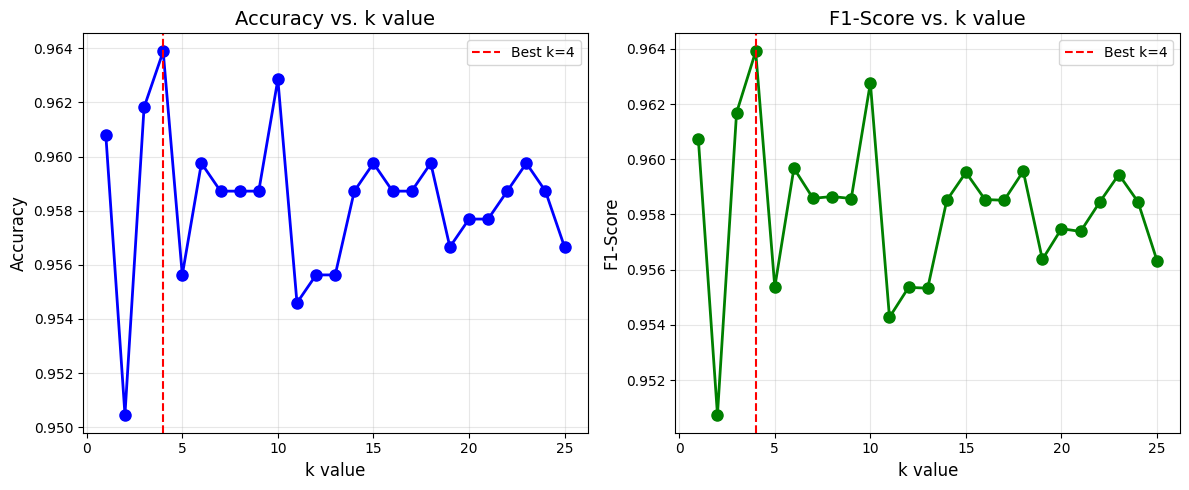


Justification: k=4 is optimal because it achieves the highest
accuracy (0.9639) and F1-score (0.9639).

3. Comparing distance metrics (Euclidean vs Manhattan):

  EUCLIDEAN distance (k=4):
    Accuracy: 0.9639
    F1-Score: 0.9639

  MANHATTAN distance (k=4):
    Accuracy: 0.9639
    F1-Score: 0.9639

Best distance metric: EUCLIDEAN

When Manhattan distance might outperform Euclidean distance:

Manhattan distance can outperform Euclidean distance in:
1. High-dimensional spaces (curse of dimensionality)
2. When features are independent or have different units
3. When there are many outliers (Manhattan is more robust)
4. In grid-like or city-block structured data
5. When the underlying data distribution is sparse



In [ ]:

print("Part 4: KNN Implementation & Hyperparameter Tuning")

# Convert labels to numeric for KNN compatibility
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_clean_encoded = label_encoder.fit_transform(y_clean)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 1. Baseline KNN with k=5
print("\n1. Baseline KNN Classifier (k=5):")
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train_encoded)
y_pred_baseline = knn_baseline.predict(X_test)

acc_baseline = accuracy_score(y_test_encoded, y_pred_baseline)
f1_baseline = f1_score(y_test_encoded, y_pred_baseline, average='weighted')

print(f"  Accuracy: {acc_baseline:.4f}")
print(f"  F1-Score: {f1_baseline:.4f}")

# 2. Hyperparameter tuning - Test k values from 1 to 25
print("\n2. Hyperparameter tuning (k values 1-25):")
k_values = range(1, 26)
accuracies = []
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train_encoded)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test_encoded, y_pred))
    f1_scores.append(f1_score(y_test_encoded, y_pred, average='weighted'))

# Find optimal k
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
best_f1 = f1_scores[np.argmax(accuracies)]

print(f"\n  Best k value: {best_k}")
print(f"  Best Accuracy: {best_accuracy:.4f}")
print(f"  Best F1-Score: {best_f1:.4f}")

# Plot Accuracy vs K
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, accuracies, 'b-o', linewidth=2, markersize=8)
plt.xlabel('k value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs. k value', fontsize=14)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_values, f1_scores, 'g-o', linewidth=2, markersize=8)
plt.xlabel('k value', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Score vs. k value', fontsize=14)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nJustification: k={best_k} is optimal because it achieves the highest")
print(f"accuracy ({best_accuracy:.4f}) and F1-score ({best_f1:.4f}).")

# 3. Compare different distance metrics
print("\n3. Comparing distance metrics (Euclidean vs Manhattan):")
metrics = ['euclidean', 'manhattan']
metric_results = {}

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train, y_train_encoded)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')
    metric_results[metric] = {'accuracy': acc, 'f1_score': f1}
    print(f"\n  {metric.upper()} distance (k={best_k}):")
    print(f"    Accuracy: {acc:.4f}")
    print(f"    F1-Score: {f1:.4f}")

# Determine best metric
best_metric = max(metric_results, key=lambda x: metric_results[x]['accuracy'])
print(f"\nBest distance metric: {best_metric.upper()}")

# 4. Discussion on Manhattan vs Euclidean
print("\n" + "="*50)
print("When Manhattan distance might outperform Euclidean distance:")
print("="*50)
print("""
Manhattan distance can outperform Euclidean distance in:
1. High-dimensional spaces (curse of dimensionality)
2. When features are independent or have different units
3. When there are many outliers (Manhattan is more robust)
4. In grid-like or city-block structured data
5. When the underlying data distribution is sparse
""")

Part 5: Confusion Matrix Analysis


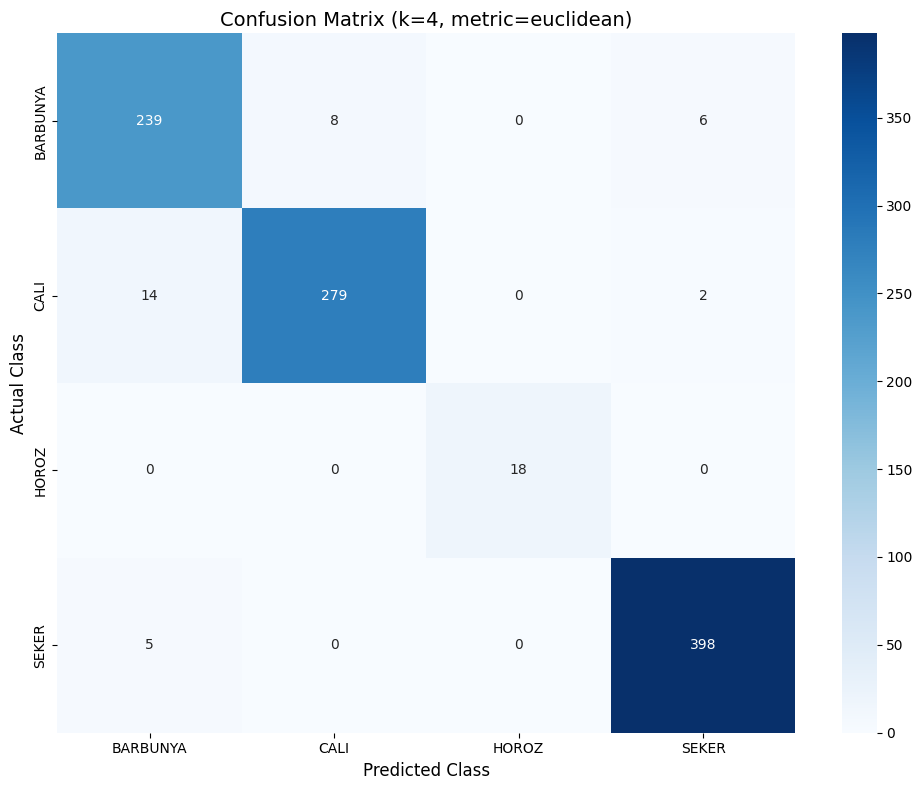


Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.94      0.94       253
        CALI       0.97      0.95      0.96       295
       HOROZ       1.00      1.00      1.00        18
       SEKER       0.98      0.99      0.98       403

    accuracy                           0.96       969
   macro avg       0.97      0.97      0.97       969
weighted avg       0.96      0.96      0.96       969


Most frequent misclassifications:
  CALI misclassified as BARBUNYA: 14 times
  BARBUNYA misclassified as CALI: 8 times
  BARBUNYA misclassified as SEKER: 6 times
  SEKER misclassified as BARBUNYA: 5 times
  CALI misclassified as SEKER: 2 times


In [ ]:

print("Part 5: Confusion Matrix Analysis")

# Train best model
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
best_knn.fit(X_train, y_train)
y_pred_best = best_knn.predict(X_test)

# 1. Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_knn.classes_,
            yticklabels=best_knn.classes_)
plt.title(f'Confusion Matrix (k={best_k}, metric={best_metric})', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Identify most frequently misclassified classes
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Find misclassifications
misclassifications = []
for i in range(len(y_test)):
    if y_test.iloc[i] != y_pred_best[i]:
        misclassifications.append((y_test.iloc[i], y_pred_best[i]))

# Count misclassification pairs
misclass_counts = Counter(misclassifications)
print("\nMost frequent misclassifications:")
for (true_class, pred_class), count in misclass_counts.most_common(5):
    print(f"  {true_class} misclassified as {pred_class}: {count} times")


In [ ]:

print("Part 6: Making KNN Faster (Optional)")

# Simple vectorized distance example
def vectorized_euclidean(X_train, X_test_point):
    """Vectorized Euclidean distance computation"""
    return np.sqrt(np.sum((X_train - X_test_point) ** 2, axis=1))

# Demonstration
sample_point = X_train[0]
distances = vectorized_euclidean(X_train, sample_point)
print(f"Vectorized distance computation for one test point: {len(distances)} distances computed")
print(f"First 5 distances: {distances[:5]}")

print("\nThis vectorization speeds up KNN significantly by avoiding Python loops")
print("and leveraging NumPy's optimized C implementations.")

Part 6: Making KNN Faster (Optional)
Vectorized distance computation for one test point: 3874 distances computed
First 5 distances: [0.         3.24988669 3.15243926 5.54303349 2.59203451]

This vectorization speeds up KNN significantly by avoiding Python loops
and leveraging NumPy's optimized C implementations.
